Computational Foundation AI – Assignment 2

11. (coding) PCA

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean



Here, i calculate the covariance matrix and find its eigenvalues and eigenvectors by performing eigendecomposition, which finds the eigenvalue decomposition of a symmetric matrix

In [10]:

cov_matrix = np.cov(X_centered.T)

print(f"Covariance matrix shape: {cov_matrix.shape}")
print(f"Covariance matrix: {cov_matrix}")

Covariance matrix shape: (4, 4)
Covariance matrix: [[ 0.68569351 -0.042434    1.27431544  0.51627069]
 [-0.042434    0.18997942 -0.32965638 -0.12163937]
 [ 1.27431544 -0.32965638  3.11627785  1.2956094 ]
 [ 0.51627069 -0.12163937  1.2956094   0.58100626]]


In [5]:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

print(f"Eigenvalues (unsorted): {eigenvalues}")
print(f"Eigenvectors shape: {eigenvectors.shape}")

Eigenvalues (unsorted): [0.02383509 0.0782095  0.24267075 4.22824171]
Eigenvectors shape: (4, 4)


Next, I sort eigenvalues in descending order and select the top 2 eigenvectors

In [6]:
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print(f"Eigenvalues (sorted): {eigenvalues}")

Eigenvalues (sorted): [4.22824171 0.24267075 0.0782095  0.02383509]


In [7]:
top_2_eigenvectors = eigenvectors[:, :2]

print(f"Top 2 Eigenvalues: {eigenvalues[:2]}")
print(f"Explained Variance: {eigenvalues[:2] / np.sum(eigenvalues) * 100}%")
print(f"Top 2 Eigenvectors shape: {top_2_eigenvectors.shape}")

Top 2 Eigenvalues: [4.22824171 0.24267075]
Explained Variance: [92.46187232  5.30664831]%
Top 2 Eigenvectors shape: (4, 2)


then i transform the original centered data into the 2D principal component space.

In [8]:
X_pca = X_centered @ top_2_eigenvectors

print(f"PCA-transformed data shape: {X_pca.shape}")
print(f"First 5 samples in PCA space:\n{X_pca[:5]}")

PCA-transformed data shape: (150, 2)
First 5 samples in PCA space:
[[ 2.68412563  0.31939725]
 [ 2.71414169 -0.17700123]
 [ 2.88899057 -0.14494943]
 [ 2.74534286 -0.31829898]
 [ 2.72871654  0.32675451]]


finally, we can plot the results like so:

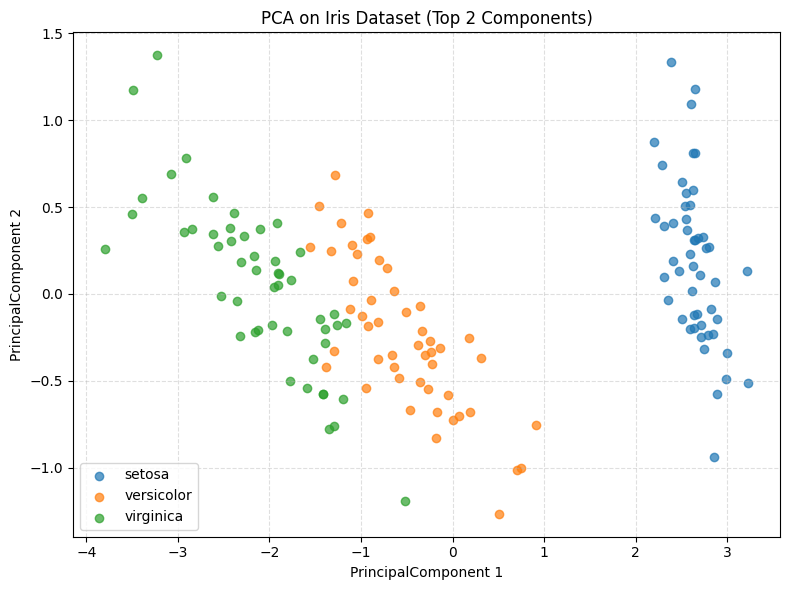

In [11]:
plt.figure(figsize=(8, 6))
for label in np.unique(y):
    plt.scatter(X_pca[y == label, 0], X_pca[y == label, 1], 
                label=iris.target_names[label], alpha=0.7)
plt.title('PCA on Iris Dataset (Top 2 Components)')
plt.xlabel('PrincipalComponent 1')
plt.ylabel('PrincipalComponent 2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()